# Final Project

#### Imports

In [48]:
from fileinput import filename

import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import string
import time
import os

### Task A - Initial Setup

#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

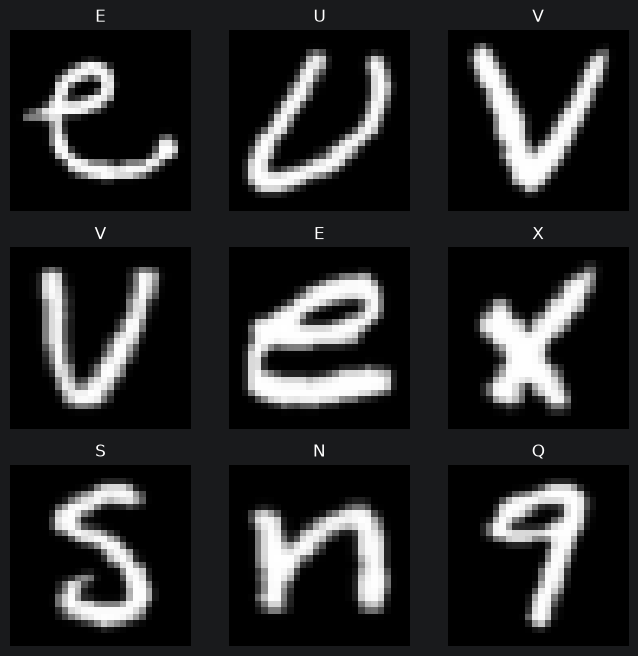

In [49]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [50]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)


##### Define CNN

In [51]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

##### Loss Function and Optimizer

In [52]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##### Training Function

In [53]:
def train(model, training_loader, criterion, optimizer):
    model.train()

    running_loss = 0
    batch_losses = []

    for images, labels in training_loader:
        labels = labels - 1

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_losses.append(loss.item())

    average_loss = running_loss / len(training_loader)

    return average_loss, batch_losses

##### Test Function

In [54]:
def test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            labels = labels - 1

            outputs = model(images)
            predictions = outputs.argmax(dim = 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

##### Training Loop

In [55]:
def training_loop(model, training_loader, criterion, optimizer, epochs):

    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = train(
            model,
            training_loader,
            criterion,
            optimizer
        )

        loss_history.append(batch_losses)

        accuracy = test(model, test_loader)

        print(
            f"Epoch {epoch+1}/{epochs}\n"
            f"Loss {avg_loss:.4f}\n"
            f"Accuracy {accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history

#loss_history = training_loop(model, training_loader, criterion, optimizer, epochs=5)

##### Training Loss Plot

In [56]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()

### Task B

#### Helper Function to Save Model

a) After you have covered all basic steps of the training process, it is time to experiment with the model architecture and the training parameters. For this you should implement a helper function to save a trained model. When saving a model, pay attention to the name you choose. Aim for names that include key information regarding the model’s architecture and/or training parameters, which makes is easy to distinguish between the different models.


In [57]:
def save_model(model, description, epochs, batch_size, layers, optimizer_name, loss_history=None, save_dir="models"):

    os.makedirs(save_dir, exist_ok=True)
    os.makedirs("figs", exist_ok=True)

    filename = (
        f"cnn_"
        f"{description}_"
        f"epo_{epochs}_"
        #f"lnr_{learning_rate}_"
        f"bts_{batch_size}_"
        f"lay_{layers}_"
        f"opt_{optimizer_name}_"
        f"tim_{time.time()}"
    )

    path = os.path.join(save_dir, filename + ".pth")

    torch.save(model.state_dict(), path)

    if loss_history is not None:
        figpath = os.path.join("figs", f"{filename}_loss_history.png")
        save_loss_plot(loss_history, filename=figpath)
        print(f"Plot saved to: {figpath}")

    print(f"Model saved to: {path}")


b) Our initial model is very simple. Your task is to define and train a new, more complex model by **adding more layers**.

In [ ]:
model_1 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)
loss_history_1 = training_loop(model_1, training_loader, criterion, optimizer_1, epochs=5)
save_model(model_1,
           description="pooling-at-end",
           epochs=5,
           batch_size=512,
           layers=7,
           optimizer_name="Adam",
           loss_history=loss_history_1)

Epoch 1/5
Loss 1.3447
Accuracy 72.42%
Epoch 2/5
Loss 0.7695
Accuracy 80.91%
Epoch 3/5
Loss 0.5863
Accuracy 83.81%
Epoch 4/5
Loss 0.4916
Accuracy 86.38%


In [ ]:
model_2 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 16 * 7 * 7, out_features=26),
)

optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)
loss_history_2 = training_loop(model_2, training_loader, criterion, optimizer_2 , epochs=5)
save_model(model_2,
           description="pooling-between",
           epochs=5,
           batch_size=512,
           layers=8,
           optimizer_name="Adam",
           loss_history=loss_history_2)

In [ ]:
model_3 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 16 * 7 * 7, out_features=64),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=64, out_features=26),
)

optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.001)
loss_history_3 = training_loop(model_3, training_loader, criterion, optimizer_3, epochs=5)
save_model(model_3,
           description="pooling-between",
           epochs=5,
           batch_size=512,
           layers=8,
           optimizer_name="Adam",
           loss_history=loss_history_3)